# Notebook For Figures S1

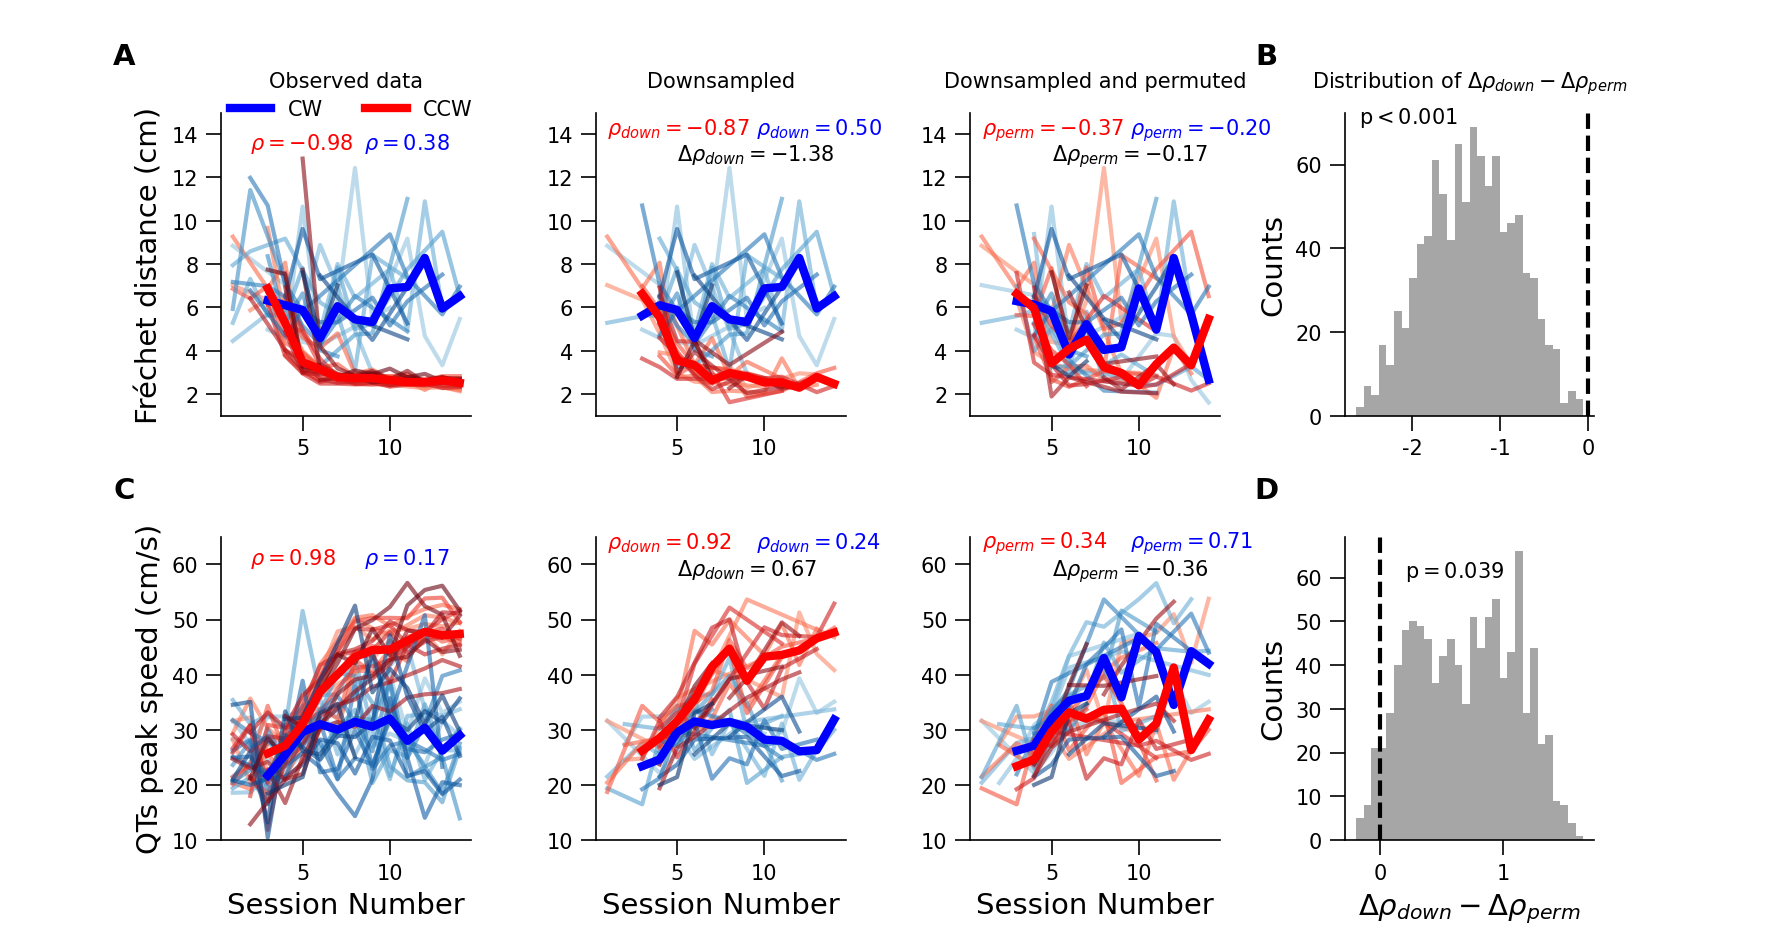

In [25]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS01.png")
display(img)


# 1. Importing necessary libraries and general functions  

In [2]:
import os
import glob
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.path as mpath
import matplotlib.cm as cm
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pickle
import scipy.ndimage as ndimage
from processing_TowerCoordinates import *
from datetime import date
from scipy.ndimage import gaussian_filter as smooth
import matplotlib.colors as mcolors
import similaritymeasures as sm
import warnings 
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr
import random
from matplotlib.cm import get_cmap


plt.style.use('paper.mplstyle')

# useful line to interupt Run all execution
# raise SystemExit("Stopping execution here.")


In [3]:
plotintermediatesteps = False 

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions that will be used for each animals

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

#path_to_data_folder='/home/david/MyLocalData/4TowersTask_MethodPaper/Group1Data'
# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/Group1Data/'
path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group1Data/'
#path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/AurelienData/'

# Analysing the entire group of mice
mice_to_analyse = [
    "MOUEml1_5", "MOUEml1_8", "MOUEml1_11", "MOUEml1_12", "MOUEml1_13", "MOUEml1_15", "MOUEml1_18", "MOUEml1_20",
    "MOURhoA_2", "MOURhoA_5", "MOURhoA_6", "MOURhoA_8", "MOURhoA_9", "MOURhoA_12", "MOURhoA_14",
    "MOUB6NN_4", "MOUB6NN_6", "MOUB6NN_13", "MOUB6NN_15"
]

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes = [0,14]
# Setting the seed for random processes used in statistics
numpy_seed = 27
np.random.seed(numpy_seed)
random_seed = 28
random.seed(a=random_seed)
# Select the offset to apply to the number of the sessions when plotting. By default, it is equal to the number of the first session.
# It resulsts in sessions being named respectively to their actual positions in the data set.
session_index_offset = first_and_last_session_indexes[0]


All mice folders are present in data folder.
 19 mice will be analysed



# 3. Chosing illustration mouse and sessions  

In [5]:
# Chose the 2 mice that are highlighted in statistics across figures
illustration_mice = ['MOUEml1_8', 'MOUEml1_5']

# Chose the color with which the illustration mice will highlighted with
illustration_colors = ['darkorange', 'green']

# Mouse that will be used as single example in this figure to show QTs trajectories and kinematics 
example_mouse_index = 0
example_mouse_bis_index = 1
example_mouse = illustration_mice[example_mouse_index]
example_mouse_bis = illustration_mice[example_mouse_bis_index]

# Chosing index of the sessions to show as examples. They are chosen by their index (session 0 is the first session etc.)
illustration_sessions_indexes = [2, 6, 13]

# coordinates in cm of the external walls of the arena
arena_coordinates_cm = [[4.5, 88.86], [90.3, 88.86], [90.3, 2.7], [4.5, 2.7]]

# Set the limits of the x-axis on the statistics plots
xlim_stats = [first_and_last_session_indexes[0]+0.5,first_and_last_session_indexes[1]+0.5]


# 4. Parameters for statistical analysis

In [6]:
MIN_TURNS = 5
N_ITER = 1000
MIN_SESSION_INDEX_FOR_RHO = 2


# 5. General functions

In [7]:
def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)

def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54

def filter_qts(qts):

    """
    Filter out QTs with length above threshold and during which more than 1 switch occured.

    Arguments:
        qts (list): list of QTs (in the original format from the pickle)

    return:
        (list): list of filtered QTs
    """

    filtered_qts = []
    
    for qt in qts:

        # Skip current QT if there is more than 1 switches
        if qt[3]['num_trapezeswitch']!=1:
            
            continue
        
        # Skip current QT if it is longer than a threshold length (30 cm)
        if qt[4]['epoch_distance']>30:

            continue

        # Keep current QT if it did not check the removal conditions
        filtered_qts.append(qt)

    return filtered_qts




### The following cells will be used to compute the median of the median Fréchet distance of each pair of flattened trajectories;

In [8]:
def towers_coordinates_as_dictionnary(towers_coordinates_cm):
    
    """
    Converts a dictionary of tower coordinates into a structured dictionary 
    where each tower's coordinates are labeled with explicit corner names.

    Arguments:
        towers_coordinates_cm (dict): Dictionary where keys are tower names and 
                                      values are lists/tuples of four coordinates.

    Returns:
        dict: A dictionary mapping tower names to their respective coordinates, 
              labeled as 'NW' (North-West), 'NE' (North-East), 'SE' (South-East), 
              and 'SW' (South-West).
    """

    # Initialize a dictionary to store labeled coordinates
    towers_coordinates_as_dict = {}

    # Predefined corner names in the order expected from input coordinates
    corner_names = ['NW', 'NE', 'SE', 'SW']

    # Map each tower's coordinates to its corresponding corner names
    for tower, coordinates in towers_coordinates_cm.items():
        towers_coordinates_as_dict[tower] = {
            corner_names[i]: coord for i, coord in enumerate(coordinates)
        }

    return towers_coordinates_as_dict

def get_tower_and_corner(run_around_tower):

    """
    Get the label of the tower and corner around wich the run around tower is happened
    based on the second and third elements saved in run_around_tower: 'N' for north, 'S' for south, 'E' for east, 'W' for west.
    
    Argument:
        run_around_tower (list): a list containing information about a run around tower

    Returns:
        str: Name of the tower around which the run occured
        str: A two character string. The first character is the name of the starting trapeze,
             the last character is the name of the ending trapeze  
    """
    
    # Extract tower name, starting name and ending trapeze name 
    tower_name = run_around_tower[1][0]
    start_trapeze = run_around_tower[1][1]
    end_trapeze = run_around_tower[2][1]
    
    # Determine the corner based on the start and end faces
    if start_trapeze == 'W' and end_trapeze == 'S':
        corner = 'SW'
    elif start_trapeze == 'S' and end_trapeze == 'E':
        corner = 'SE'
    elif start_trapeze == 'E' and end_trapeze == 'N':
        corner = 'NE'
    elif start_trapeze == 'N' and end_trapeze == 'W':
        corner = 'NW'
    elif start_trapeze == 'W' and end_trapeze == 'N':
        corner = 'NW'
    elif start_trapeze == 'N' and end_trapeze == 'E':
        corner = 'NE'
    elif start_trapeze == 'E' and end_trapeze == 'S':
        corner = 'SE'
    elif start_trapeze == 'S' and end_trapeze == 'W':
        corner = 'SW'
    else:
        corner = None  # Handle unexpected cases
    
    return tower_name, corner

def rotate_sw_trajectory_90_ccw(trajectory):
    
    """
    Rotates the input trajectory of 90° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 90° counter-clockwise

    """
    
    # Define the roation matrix
    rotation_matrix = np.array([[0, -1], [1, 0]])
    
    # Returns the matrix product of the rotation matrix and the trajectory 
    return rotation_matrix @ trajectory

def rotate_nw_trajectory_180_ccw(trajectory):

    """
    Rotates the input trajectory of 180° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 180° counter-clockwise

    """

    return -trajectory

def rotate_ne_trajectory_270_ccw(trajectory):
    
    """
    Rotates the input trajectory of 270° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 270° counter-clockwise

    """
    
    # Define the roation matrix
    rotation_matrix = np.array([[0, 1], [-1, 0]])

    # Returns the matrix product of the rotation matrix and the trajectory 
    return rotation_matrix @ trajectory

def compute_frechet_distances(runs_list):

    """
    This function takes a list of trajectories of dimensions (2,N), computes the Fréchet distance 
    between each pairs of trajectories, and returns the median of those distances.
    
    Arguments:
        runs_list (list): List of trajectories of dimensions (2,N)

    Return:
        (float): Median of the Fréchet distances of all trajectories pairs
    
    """

    # Create an empty list that will contain the Fréchet distances of all trajectories pairs
    frechet_distances_list = []

    # Iterate on all trajectories
    for i in range(len(runs_list)):

        # Transpose the trajectory
        # This step is necessary as the function that computes the Fréchet distance takes as an argument trajectories of dimensions (N,2)
        traj_points_a = np.transpose(runs_list[i])

        # Iterate on every trajectories of higher ranks to create trajectories pairs
        # We do that so that no pairs is counted twice, as the Fréchet distance between trajectory A and B is the same as between B and A
        for j in range(i+1, len(runs_list)):

            # Transpose the trajectory
            traj_points_b = np.transpose(runs_list[j])

            # Compute the Fréchet distance for the current pair of trajectories
            frechet_distance = sm.frechet_dist(traj_points_a,traj_points_b)

            # Store the result in a list
            frechet_distances_list.append(frechet_distance)

    # Return the median of the list of Fréchet distances
    return frechet_distances_list


### This cell process the runs around tower trajectory such that:
- All runs around tower with the same starting and ending trapeze and are shifted to have their origin on the same axis, independently of the tower where they occur.
- All runs around tower are rotated from 90°/180°/270° counter-clockwise when the corner around which the mouse turns is South-West/North-West/North-East.
- Does so separately for turns in clockwise and counter-clockwise direction.

In [9]:
# Initialize a dictionary to store all trajectories for each mouse, with empty lists for each session
mice_alltrajectories_persession = {mouse: {} for mouse in mice_to_analyse}

# Initialize a dictionary to store realigned and rotated trajectories for each mouse, with empty dictionaries for each session
trajectories_per_session_realigned_rotated = {mouse: {} for mouse in mice_to_analyse}

# Loop through each mouse in the list of mice to realign all their turns trajectory
for mouse in mice_to_analyse:
    # Define the folder path for the current mouse
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get a sorted list of session folders for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    # Get the number of sessions to process
    nb_sessions = len(sessions_to_process)
    print(f'Processing mouse {mouse}. There is/are {nb_sessions} sessions to process:')
    print(sessions_to_process, '\n')

    # Loop through each session for the current mouse to realign all the turns trajectory from those sessions
    for session_index, session_to_process in enumerate(sessions_to_process):
        print(f'Getting the run trajectory of session {session_index}')

        # Define the path to the pickle file for the current session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

          # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            continue

        # Load the data from the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Initialize entries for the current session in the dictionaries
        mice_alltrajectories_persession[mouse][session_index] = []
        trajectories_per_session_realigned_rotated[mouse][session_index] = {'CW':[], 'CCW':[]}

        # Get the runs around the tower for the current session
        runs_around_tower = filter_qts(session_data['all_epochs']['run_around_tower'])
        # Get the trajectory of the mouse
        positions = np.array(session_data['positions'])

        # Get the tower coordinates and convert them to a dictionary format
        towers_coordinates_cm = session_data['towers_coordinates_cm']
        towers_coordinates_as_dict = towers_coordinates_as_dictionnary(towers_coordinates_cm)

        # Loop through each run around the tower to realign them
        for run_around_tower in runs_around_tower:
            # Only process runs around tower where there was only one trapeze switch 
            if run_around_tower[3]['num_trapezeswitch'] == 1:
                # Extract the run trajectory
                run_trajectory = positions[:, run_around_tower[0][0]:run_around_tower[0][1]]
                mice_alltrajectories_persession[mouse][session_index].append(run_trajectory)

                # Get the tower and corner names
                tower_name, corner = get_tower_and_corner(run_around_tower)

                # Access tower and corner coordinates from the dictionary
                if tower_name in towers_coordinates_as_dict and corner in towers_coordinates_as_dict[tower_name]:
                    this_corner_coordinates = towers_coordinates_as_dict[tower_name][corner]
                else:
                    print(f"Invalid tower or corner: {tower_name}, {corner}")
                    continue

                # Extract the trajectory slice based on the start and end time indices
                start_idx, end_idx = run_around_tower[0]
                this_trajectory = positions[:, start_idx:end_idx]

                # Get the corner's reference coordinates (X and Y)
                newXreference = this_corner_coordinates[0]
                newYreference = this_corner_coordinates[1]

                # Shift the trajectory to reference the new corner coordinates
                this_trajectory[0, :] -= newXreference  # Shift X coordinates
                this_trajectory[1, :] -= newYreference  # Shift Y coordinates

                # Rotate the trajectory based on the corner
                if corner == 'SW':
                    this_trajectory = rotate_sw_trajectory_90_ccw(this_trajectory)
                elif corner == 'NW':
                    this_trajectory = rotate_nw_trajectory_180_ccw(this_trajectory)
                elif corner == 'NE':
                    this_trajectory = rotate_ne_trajectory_270_ccw(this_trajectory)

                # Get the direction (CW or CCW)
                direction = run_around_tower[3]['direction']

                # Append the transformed trajectory to the appropriate list based on direction
                trajectories_per_session_realigned_rotated[mouse][session_index][direction].append(this_trajectory)   


Processing mouse MOUEml1_5. There is/are 14 sessions to process:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615'] 

Getting the run trajectory of session 0
Getting the run trajectory of session 1
Invalid tower or corner: NW, None
Getting the run trajectory of session 2
Invalid tower or corner: SW, None
Invalid tower or corner: SW, None
Getting the run trajectory of session 3
Invalid tower or corner: SW, None
Invalid tower or corner: SW, None
Invalid tower or corner: SW, None
Invalid tower or corner: SW, None
Getting the run trajectory of session 4
Invalid tower or corner: NW, None
Getting the run trajectory of session 5
Getting the run trajectory of session 6
Ge

In [10]:
pickle_path = "median_frechet_by_mouse_session_direction.pkl"
overwrite = False  # set True to recompute

# -----------------------------
# Load if exists
# -----------------------------
if os.path.exists(pickle_path) and not overwrite:
    print(f"Loading saved median Fréchet distances from {pickle_path}")
    with open(pickle_path, "rb") as f:
        median_frechet_by_mouse_session_direction = pickle.load(f)

# -----------------------------
# Otherwise compute and save
# -----------------------------
else:
    print("Computing median Fréchet distances from scratch...")

    median_frechet_by_mouse_session_direction = {}

    for mouse, sessions in trajectories_per_session_realigned_rotated.items():
        median_frechet_by_mouse_session_direction[mouse] = {}
        for s, directions in sessions.items():
            median_vals = {"CW": np.nan, "CCW": np.nan}

            # CW
            cw_trajs = directions.get("CW", [])
            if len(cw_trajs) >= 5:
                median_vals["CW"] = np.nanmedian(compute_frechet_distances(cw_trajs))

            # CCW
            ccw_trajs = directions.get("CCW", [])
            if len(ccw_trajs) >= 5:
                median_vals["CCW"] = np.nanmedian(compute_frechet_distances(ccw_trajs))

            median_frechet_by_mouse_session_direction[mouse][direction][s] = median_vals

    # Save results
    with open(pickle_path, "wb") as f:
        pickle.dump(median_frechet_by_mouse_session_direction, f)
    print(f"Saved median Fréchet distances to {pickle_path}")



Loading saved median Fréchet distances from median_frechet_by_mouse_session_direction.pkl


In [11]:
def plot_func_frechet_1(ax, median_frechet_by_mouse_session_direction, cw_text_loc=(1,1), ccw_text_loc=(1,1), show_xlabel=True,  show_ylabel=True):

    mice = list(median_frechet_by_mouse_session_direction.keys())
    n_mice = len(mice)

    cmap_cw = plt.cm.Blues
    cmap_ccw = plt.cm.Reds

    # -----------------------------
    # Collect per-mouse per-session median
    # -----------------------------
    median_cw_all = {}
    median_ccw_all = {}

    for i, mouse in enumerate(mice):

        color_cw = cmap_cw(0.4 + 0.6 * i / max(1, n_mice - 1))
        color_ccw = cmap_ccw(0.4 + 0.6 * i / max(1, n_mice - 1))

        sessions = sorted(median_frechet_by_mouse_session_direction[mouse].keys())
        cw_vals = []
        ccw_vals = []

        for s in sessions:
            cw = median_frechet_by_mouse_session_direction[mouse][s]["CW"]
            ccw = median_frechet_by_mouse_session_direction[mouse][s]["CCW"]

            # Only keep if enough trajectories (NaNs are already set if <5)
            cw_vals.append(cw)
            ccw_vals.append(ccw)

        sessions = np.array(sessions)
        sessions_plot = sessions + 1  # shift for plotting
        cw_vals = np.array(cw_vals)
        ccw_vals = np.array(ccw_vals)

        median_cw_all[mouse] = dict(zip(sessions, cw_vals))
        median_ccw_all[mouse] = dict(zip(sessions, ccw_vals))

        # --- Plot individual mice (continuous lines over valid points) ---
        valid = ~np.isnan(cw_vals)
        if np.sum(valid) >= 2:
            ax.plot(sessions_plot[valid], cw_vals[valid], color=color_cw, alpha=0.6, linewidth=1)

        valid = ~np.isnan(ccw_vals)
        if np.sum(valid) >= 2:
            ax.plot(sessions_plot[valid], ccw_vals[valid], color=color_ccw, alpha=0.6, linewidth=1)

    # -----------------------------
    # Group median per session
    # -----------------------------
    all_sessions = sorted(sessions)
    group_median_cw = []
    group_median_ccw = []

    for s in all_sessions:
        group_median_cw.append(np.nanmedian([median_cw_all[m].get(s, np.nan) for m in mice]))
        group_median_ccw.append(np.nanmedian([median_ccw_all[m].get(s, np.nan) for m in mice]))

    group_median_cw = np.array(group_median_cw)
    group_median_ccw = np.array(group_median_ccw)
    all_sessions = np.array(all_sessions)
    all_sessions_plot = all_sessions + 1

    # -----------------------------
    # Spearman correlation (from 3rd session)
    # -----------------------------
    mask = all_sessions >= all_sessions[MIN_SESSION_INDEX_FOR_RHO]
    rho_cw, _ = spearmanr(all_sessions[mask], group_median_cw[mask])
    rho_ccw, _ = spearmanr(all_sessions[mask], group_median_ccw[mask])

    # -----------------------------
    # Plot group medians
    # -----------------------------
    ax.plot(all_sessions_plot[mask], group_median_cw[mask], color="blue", linewidth=2, label='CW')
    ax.plot(all_sessions_plot[mask], group_median_ccw[mask], color="red", linewidth=2, label='CCW')

    ax.text(cw_text_loc[0], cw_text_loc[1], rf"$\rho={rho_cw:.2f}$", fontsize=5, color='blue')
    ax.text(ccw_text_loc[0], ccw_text_loc[1], rf"$\rho={rho_ccw:.2f}$", fontsize=5, color='red')

    if show_xlabel:
        ax.set_xlabel("Session")
    if show_ylabel:
        ax.set_ylabel("Fréchet distance (cm)")
    ax.set_title("Observed data", fontsize=5)
    ax.legend(loc=(0,0.95), ncols=2, frameon=False)

In [12]:
if plotintermediatesteps:
    
    fig=plt.figure(figsize=(cm2inch(7), cm2inch(7)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)
    row1 = gs[0].subgridspec(1, 1)
    ax = plt.subplot(row1[:])


    plot_func_frechet_1(ax, median_frechet_by_mouse_session_direction)


In [13]:

def plot_func_frechet_2(ax, trajectories_per_session_realigned_rotated, swaping=False, title='', cw_text_loc=(1,1), ccw_text_loc=(1,1), delta_text_loc=(1,1), show_xlabel=True,  show_ylabel=True):

    mice = list(trajectories_per_session_realigned_rotated.keys())
    n_mice = len(mice)

    cmap_cw = plt.cm.Blues
    cmap_ccw = plt.cm.Reds

    # ------------------------------
    # 1. Compute median Frechet per mouse/session (CCW downsampled to CW)
    # ------------------------------
    median_cw_all = {}
    median_ccw_ds_all = {}

    for i, mouse in enumerate(mice):
        sessions = sorted(trajectories_per_session_realigned_rotated[mouse].keys())

        cw_vals = []
        ccw_vals = []

        for s in sessions:
            cw_trajs = trajectories_per_session_realigned_rotated[mouse][s].get("CW", [])
            ccw_trajs = trajectories_per_session_realigned_rotated[mouse][s].get("CCW", [])

            n_cw = len(cw_trajs)
            n_ccw = len(ccw_trajs)

            if n_cw < MIN_TURNS or n_ccw < MIN_TURNS:
                cw_vals.append(np.nan)
                ccw_vals.append(np.nan)
                continue

            cw_vals.append(np.nanmedian(compute_frechet_distances(cw_trajs)))

            # CCW downsampled to CW count
            ccw_ds = random.sample(ccw_trajs, n_cw) if n_ccw > n_cw else ccw_trajs
            ccw_vals.append(np.nanmedian(compute_frechet_distances(ccw_ds)))

        median_cw_all[mouse] = dict(zip(sessions, cw_vals))
        median_ccw_ds_all[mouse] = dict(zip(sessions, ccw_vals))

    # ------------------------------
    # 2. Plot original CCW-downsampled vs CW
    # ------------------------------
    
    median_cw = {}
    median_ccw = {}

    for i, mouse in enumerate(mice):
        sessions = np.array(sorted(median_cw_all[mouse].keys()))
        sessions_plot = sessions + 1

        cw_vals_temp = np.array([median_cw_all[mouse][s] for s in sessions])
        ccw_vals_temp = np.array([median_ccw_ds_all[mouse][s] for s in sessions])

        if swaping:
            # Randomly swap labels for this mouse
            if random.random() < 0.5:
                cw_vals, ccw_vals = cw_vals_temp, ccw_vals_temp
            else:
                cw_vals, ccw_vals = ccw_vals_temp, cw_vals_temp

        else:
        
            cw_vals, ccw_vals = cw_vals_temp, ccw_vals_temp

        median_cw[mouse] = dict(zip(sessions, cw_vals))
        median_ccw[mouse] = dict(zip(sessions, ccw_vals))

        color_cw = cmap_cw(0.4 + 0.6 * i / max(1, n_mice - 1))
        color_ccw = cmap_ccw(0.4 + 0.6 * i / max(1, n_mice - 1))

        valid = ~np.isnan(cw_vals)
        if np.sum(valid) >= 2:
            ax.plot(sessions_plot[valid], cw_vals[valid], color=color_cw, alpha=0.6, linewidth=1)

        valid = ~np.isnan(ccw_vals)
        if np.sum(valid) >= 2:
            ax.plot(sessions_plot[valid], ccw_vals[valid], color=color_ccw, alpha=0.6, linewidth=1)

    # Group median
    all_sessions = sorted(sessions)
    group_median_cw = []
    group_median_ccw = []

    for s in all_sessions:
        group_median_cw.append(np.nanmedian([median_cw[m].get(s, np.nan) for m in mice]))
        group_median_ccw.append(np.nanmedian([median_ccw[m].get(s, np.nan) for m in mice]))

    group_median_cw = np.array(group_median_cw)
    group_median_ccw = np.array(group_median_ccw)
    all_sessions = np.array(all_sessions)  # make sure it’s numpy
    all_sessions_plot = all_sessions + 1   # for plotting

    # Spearman from third session
    mask = all_sessions >= all_sessions[MIN_SESSION_INDEX_FOR_RHO]
    rho_cw, _ = spearmanr(all_sessions[mask], group_median_cw[mask])
    rho_ccw, _ = spearmanr(all_sessions[mask], group_median_ccw[mask])

    ax.plot(all_sessions_plot[mask], group_median_cw[mask], color="blue", linewidth=2)
    ax.plot(all_sessions_plot[mask], group_median_ccw[mask], color="red", linewidth=2)
    
    cw_text_to_plot = rf'$\rho_{{perm}}={rho_cw:.2f}$' if swaping else rf'$\rho_{{down}}={rho_cw:.2f}$'
    ccw_text_to_plot = rf'$\rho_{{perm}}={rho_ccw:.2f}$' if swaping else rf'$\rho_{{down}}={rho_ccw:.2f}$'

    ax.text(cw_text_loc[0], cw_text_loc[1], cw_text_to_plot, fontsize=5, color='blue')
    ax.text(ccw_text_loc[0], ccw_text_loc[1], ccw_text_to_plot, fontsize=5, color='red')

    if swaping:

        ax.text(delta_text_loc[0], delta_text_loc[1], rf'$\Delta \rho_{{perm}} = {np.round(rho_ccw - rho_cw,2)}$', fontsize=5, color='k')
    
    else:

        ax.text(delta_text_loc[0], delta_text_loc[1], rf'$\Delta \rho_{{down}} = {np.round(rho_ccw - rho_cw,2)}$', fontsize=5, color='k')

    if show_xlabel:
        ax.set_xlabel("Session")
    if show_ylabel:
        ax.set_ylabel("Median Fréchet distance (cm)")

    ax.set_title(title, fontsize=5)



In [14]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(15), cm2inch(7)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)
    row1 = gs[0].subgridspec(1, 2)
    ax_1 = plt.subplot(row1[0,0])
    ax_2 = plt.subplot(row1[0,1])

    plot_func_frechet_2(ax_1, trajectories_per_session_realigned_rotated, swaping=False, title='Undersampled\nFréchet distance)', cw_text_loc=(10,12.2), ccw_text_loc=(10,11.2))
    plot_func_frechet_2(ax_2, trajectories_per_session_realigned_rotated, swaping=True, title='Undersampled and permuted\nFréchet distance', cw_text_loc=(10,12.2), ccw_text_loc=(10,11.2))

In [15]:

overwrite = False

if overwrite:

    # -------------------------
    # Output lists
    # -------------------------
    rho_cw_list = []
    rho_ccw_list = []
    rho_cw_perm_list = []
    rho_ccw_perm_list = []

    mice = list(trajectories_per_session_realigned_rotated.keys())
    pickle_path = "median_frechet_by_mouse_session_direction.pkl"

    with open(pickle_path, "rb") as f:
        median_frechet_by_mouse_session_direction = pickle.load(f)

    # -------------------------
    # Loop over iterations
    # -------------------------
    for it in range(N_ITER):

        median_cw_all = {}
        median_ccw_ds_all = {}

        # --- 1. Compute median per mouse per session (CCW downsampled if needed) ---
        for mouse in mice:

            sessions = sorted(trajectories_per_session_realigned_rotated[mouse].keys())

            cw_vals = []
            ccw_vals = []

            for s in sessions:
                cw_trajs = trajectories_per_session_realigned_rotated[mouse][s].get("CW", [])
                ccw_trajs = trajectories_per_session_realigned_rotated[mouse][s].get("CCW", [])

                n_cw = len(cw_trajs)
                n_ccw = len(ccw_trajs)

                # Require at least 5 CW and 5 CCW
                if n_cw < MIN_TURNS or n_ccw < MIN_TURNS:
                    cw_vals.append(np.nan)
                    ccw_vals.append(np.nan)
                    continue

                # CW median: use saved median if available
                cw_vals.append(median_frechet_by_mouse_session_direction[mouse][s]['CW'])

                # CCW downsampled to CW count
                if n_ccw > n_cw:
                    ccw_ds = random.sample(ccw_trajs, n_cw)
                    ccw_vals.append(np.nanmedian(compute_frechet_distances(ccw_ds)))
                else:
                    ccw_vals.append(median_frechet_by_mouse_session_direction[mouse][s]['CCW'])

            median_cw_all[mouse] = dict(zip(sessions, cw_vals))
            median_ccw_ds_all[mouse] = dict(zip(sessions, ccw_vals))

        # --- 2. Group median per session ---
        all_sessions = sorted(sessions)
        group_median_cw = np.array([np.nanmedian([median_cw_all[m].get(s, np.nan) for m in mice]) for s in all_sessions])
        group_median_ccw = np.array([np.nanmedian([median_ccw_ds_all[m].get(s, np.nan) for m in mice]) for s in all_sessions])
        all_sessions = np.array(all_sessions)

        # --- 3. Compute Spearman rho from session 3 onward ---
        mask = all_sessions >= all_sessions[MIN_SESSION_INDEX_FOR_RHO]
        rho_cw = spearmanr(all_sessions[mask], group_median_cw[mask])[0]
        rho_ccw = spearmanr(all_sessions[mask], group_median_ccw[mask])[0]

        rho_cw_list.append(rho_cw)
        rho_ccw_list.append(rho_ccw)

        # --- 4. Permute CW/CCW labels per mouse and recompute group median & rho ---
        median_cw_perm_all = {}
        median_ccw_perm_all = {}

        for mouse in mice:
            median_cw_perm_all[mouse] = {}
            median_ccw_perm_all[mouse] = {}
            for s in all_sessions:
                val_cw = median_cw_all[mouse].get(s, np.nan)
                val_ccw = median_ccw_ds_all[mouse].get(s, np.nan)
                if np.random.rand() < 0.5:
                    median_cw_perm_all[mouse][s] = val_cw
                    median_ccw_perm_all[mouse][s] = val_ccw
                else:
                    median_cw_perm_all[mouse][s] = val_ccw
                    median_ccw_perm_all[mouse][s] = val_cw

        group_median_cw_perm = np.array([np.nanmedian([median_cw_perm_all[m].get(s, np.nan) for m in mice]) for s in all_sessions])
        group_median_ccw_perm = np.array([np.nanmedian([median_ccw_perm_all[m].get(s, np.nan) for m in mice]) for s in all_sessions])

        rho_cw_perm = spearmanr(all_sessions[mask], group_median_cw_perm[mask])[0]
        rho_ccw_perm = spearmanr(all_sessions[mask], group_median_ccw_perm[mask])[0]

        rho_cw_perm_list.append(rho_cw_perm)
        rho_ccw_perm_list.append(rho_ccw_perm)

        if (it + 1) % 10 == 0:
            print(f"Iteration {it+1}/{N_ITER} done")

    # -------------------------
    # Convert to arrays and save
    # -------------------------
    rho_cw_list = np.array(rho_cw_list)
    rho_ccw_list = np.array(rho_ccw_list)
    rho_cw_perm_list = np.array(rho_cw_perm_list)
    rho_ccw_perm_list = np.array(rho_ccw_perm_list)

    with open("rho_frechet_downsampled_perm.pkl", "wb") as f:
        pickle.dump({
            "rho_cw": rho_cw_list,
            "rho_ccw": rho_ccw_list,
            "rho_cw_perm": rho_cw_perm_list,
            "rho_ccw_perm": rho_ccw_perm_list
        }, f)

    print("Saved bootstrap results to rho_frechet_downsampled_perm.pkl")


In [16]:
if plotintermediatesteps:

    # -----------------------------
    # Load saved results
    # -----------------------------
    with open("rho_frechet_downsampled_perm.pkl", "rb") as f:
        results = pickle.load(f)

    rho_cw = results["rho_cw"]
    rho_ccw = results["rho_ccw"]
    rho_cw_perm = results["rho_cw_perm"]
    rho_ccw_perm = results["rho_ccw_perm"]

    # -----------------------------
    # Compute delta difference per iteration
    # Δρ_down - Δρ_perm
    # -----------------------------
    delta_down_minus_perm = (rho_ccw - rho_cw) - (rho_ccw_perm - rho_cw_perm)

    # -----------------------------
    # Compute fraction of iterations where delta < 0
    # This gives the proportion of iterations where the down difference exceeds permuted
    # -----------------------------
    p_value = np.mean(delta_down_minus_perm >= 0)
    print(f"Fraction of iterations where Δρ_down > Δρ_perm: {1 - p_value:.3f}")
    print(f"p-value (Δρ_down ≤ Δρ_perm): {p_value:.4f}")

    # -----------------------------
    # Plot distribution of Δρ_down - Δρ_perm
    # -----------------------------
    plt.figure(figsize=(7,5))
    plt.hist(delta_down_minus_perm, bins=30, color='gray', edgecolor='black', alpha=0.7)
    plt.axvline(0, color='red', linestyle='--', label='0')
    plt.xlabel("Δρ_down - Δρ_perm")
    plt.ylabel("Counts")
    plt.title("Distribution of Δρ_down - Δρ_perm (median Fréchet)")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Panel B

# Computations for max speed

### This cell computes and store the median of the turns maximum speed.

In [17]:
# Initialize dictionaries to store the various metrics for each mouse
mice_all_maximum_ccw_turn_speed_persession = {mouse: {} for mouse in mice_to_analyse}
mice_all_maximum_cw_turn_speed_persession = {mouse: {} for mouse in mice_to_analyse}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([
        name for name in os.listdir(folder_path_mouse_to_process)
        if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
        and name.startswith('MOU')
    ])

    # Limit to the subset of sessions we want
    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')

    # Process each session for the current mouse
    for session_index, session_to_process in enumerate(sessions_to_process):

        # Define the pickle file path for the session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping.')
            mice_all_maximum_ccw_turn_speed_persession[mouse][session_index] = [np.nan]
            mice_all_maximum_cw_turn_speed_persession[mouse][session_index] = [np.nan]

            continue

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Initialize lists to store turn speeds
        cw_turns_max_speed = []
        ccw_turns_max_speed = []

        # Iterate through each run around the tower
        qts_list = filter_qts(session_data['all_epochs']['run_around_tower'])
        
        for run in qts_list:
            
            direction = run[3].get('direction', None)
            max_speed = run[4]['epoch_maxspeed'] #run[4].get("epoch_maxspeed", np.nan)

            if direction == 'CW':
                cw_turns_max_speed.append(max_speed)
            elif direction == 'CCW':
                ccw_turns_max_speed.append(max_speed)

        # Safely compute median (np.nanmedian handles empty lists)
        median_cw = np.nanmedian(cw_turns_max_speed) if cw_turns_max_speed else np.nan
        median_ccw = np.nanmedian(ccw_turns_max_speed) if ccw_turns_max_speed else np.nan

        # Append session data
        mice_all_maximum_cw_turn_speed_persession[mouse][session_index] = cw_turns_max_speed
        mice_all_maximum_ccw_turn_speed_persession[mouse][session_index] = ccw_turns_max_speed


Mouse MOUEml1_5. There is/are 14 sessions:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615'] 

Mouse MOUEml1_8. There is/are 14 sessions:
['MOUEml1_8_20230420-1740', 'MOUEml1_8_20230421-1132', 'MOUEml1_8_20230422-1145', 'MOUEml1_8_20230422-1748', 'MOUEml1_8_20230423-1156', 'MOUEml1_8_20230423-1725', 'MOUEml1_8_20230424-1118', 'MOUEml1_8_20230424-1724', 'MOUEml1_8_20230425-1119', 'MOUEml1_8_20230425-1740', 'MOUEml1_8_20230426-1137', 'MOUEml1_8_20230426-1720', 'MOUEml1_8_20230427-1146', 'MOUEml1_8_20230427-1708'] 

Mouse MOUEml1_11. There is/are 14 sessions:
['MOUEml1_11_20230420-1906', 'MOUEml1_11_20230421-1239', 'MOUEml1_11_20230422-1250', 'MOUEml1_11_20230422-18

In [18]:
def plot_func(ax, mice_all_maximum_cw_turn_speed_persession, mice_all_maximum_ccw_turn_speed_persession, resampling = False, swaping = False, cw_text_loc=(1,1), ccw_text_loc=(1,1), delta_text_loc=(1,1), title = '', show_xlabel=True,  show_ylabel=True):

    mice = list(mice_all_maximum_cw_turn_speed_persession.keys())
    n_mice = len(mice)
    
    cmap_cw = plt.cm.Blues
    cmap_ccw = plt.cm.Reds

    median_cw_all = {}
    median_ccw_all = {}

    sessions = sorted(next(iter(mice_all_maximum_cw_turn_speed_persession.values())).keys())
    sessions = np.array(sessions)
    sessions_plot = sessions + 1

    for mouse in mice:

        cw_vals = []
        ccw_vals = []

        for s in sessions:
            cw = mice_all_maximum_cw_turn_speed_persession[mouse].get(s, [])
            ccw = mice_all_maximum_ccw_turn_speed_persession[mouse].get(s, [])

            if resampling or swaping:

                if len(cw) < MIN_TURNS or len(ccw) < MIN_TURNS:
                    cw_vals.append(np.nan)
                    ccw_vals.append(np.nan)
                    continue

            cw_vals.append(np.median(cw))

            if resampling:
                # Resample
                if len(ccw) > len(cw):
                    ccw_ds = random.sample(ccw, len(cw))
                else:
                    ccw_ds = ccw
            
                ccw_vals.append(np.median(ccw_ds))

            else:
            
                ccw_vals.append(np.median(ccw))
            #
            

        median_cw_all[mouse] = np.array(cw_vals)
        median_ccw_all[mouse] = np.array(ccw_vals)

    cw_all = []
    ccw_all = []

    for i, mouse in enumerate(mice):

        color_cw = cmap_cw(0.4 + 0.6 * i / max(1, n_mice - 1))
        color_ccw = cmap_ccw(0.4 + 0.6 * i / max(1, n_mice - 1))

        cw_vals = copy.deepcopy(median_cw_all[mouse])
        ccw_vals = copy.deepcopy(median_ccw_all[mouse])

        if swaping:

            # Random swap at mouse level
            if np.random.rand() < 0.5:
                cw_vals, ccw_vals = cw_vals, ccw_vals

            else:
                cw_vals, ccw_vals = ccw_vals, cw_vals
            
        cw_all.append(cw_vals)
        ccw_all.append(ccw_vals)

        #

        valid = ~np.isnan(cw_vals)
        if valid.sum() >= 2:
            ax.plot(sessions_plot[valid], cw_vals[valid],
                    color=color_cw, alpha=0.6, linewidth=1)

        valid = ~np.isnan(ccw_vals)
        if valid.sum() >= 2:
            ax.plot(sessions_plot[valid], ccw_vals[valid],
                    color=color_ccw, alpha=0.6, linewidth=1)

    group_cw = np.nanmedian(cw_all, axis=0)
    group_ccw = np.nanmedian(ccw_all, axis=0)


    mask = sessions >= sessions[MIN_SESSION_INDEX_FOR_RHO]

    rho_cw, _ = spearmanr(sessions[mask], group_cw[mask])
    rho_ccw, _ = spearmanr(sessions[mask], group_ccw[mask])

    ax.plot(sessions_plot[mask], group_cw[mask],
            color="blue", linewidth=2)

    ax.plot(sessions_plot[mask], group_ccw[mask],
            color="red", linewidth=2)


    cw_text_to_plot = rf"$\rho={rho_cw:.2f}$"
    ccw_text_to_plot = rf"$\rho={rho_ccw:.2f}$"
    
    if resampling:

        cw_text_to_plot = rf"$\rho_{{down}}={rho_cw:.2f}$"
        ccw_text_to_plot = rf"$\rho_{{down}}={rho_ccw:.2f}$"

    if swaping:

        cw_text_to_plot = rf"$\rho_{{perm}}={rho_cw:.2f}$"
        ccw_text_to_plot = rf"$\rho_{{perm}}={rho_ccw:.2f}$"


    ax.text(cw_text_loc[0], cw_text_loc[1], cw_text_to_plot, fontsize=5, color='blue')
    ax.text(ccw_text_loc[0], ccw_text_loc[1], ccw_text_to_plot, fontsize=5, color='red')

    if swaping and resampling:

        ax.text(delta_text_loc[0], delta_text_loc[1], rf'$\Delta \rho_{{perm}} = {np.round(rho_ccw - rho_cw,2)}$', fontsize=5, color='k')
    
    elif not(swaping) and resampling:

        ax.text(delta_text_loc[0], delta_text_loc[1], rf'$\Delta \rho_{{down}} = {np.round(rho_ccw - rho_cw,2)}$', fontsize=5, color='k')

    if show_xlabel:
        ax.set_xlabel("Session Number")
    if show_ylabel:
        
        ax.set_ylabel("QTs peak speed (cm/s)")
    ax.set_title(title, fontsize=5)
    

In [19]:
if plotintermediatesteps:
    
    fig=plt.figure(figsize=(cm2inch(7), cm2inch(7)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)
    row1 = gs[0].subgridspec(1, 1)
    ax = plt.subplot(row1[:])


    plot_func(ax, mice_all_maximum_cw_turn_speed_persession, mice_all_maximum_ccw_turn_speed_persession, resampling = False, swaping = False, title = 'Peak speed', cw_text_loc=(1,50), ccw_text_loc=(1,45))



In [20]:
if plotintermediatesteps:
    
    fig=plt.figure(figsize=(cm2inch(15), cm2inch(7)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.3)
    row1 = gs[0].subgridspec(1, 2)
    ax_1 = plt.subplot(row1[0])
    ax_2 = plt.subplot(row1[1])


    plot_func(ax_1, mice_all_maximum_cw_turn_speed_persession, mice_all_maximum_ccw_turn_speed_persession, resampling = True, swaping = False, title = 'Undersampled\npeak speed', cw_text_loc=(1,50), ccw_text_loc=(1,45))

    plot_func(ax_2, mice_all_maximum_cw_turn_speed_persession, mice_all_maximum_ccw_turn_speed_persession, resampling = True, swaping = True, title = 'Undersampled and permuted\npeak speed', cw_text_loc=(1,50), ccw_text_loc=(1,45))


In [21]:

overwrite = False

if overwrite:
    
    mice = list(mice_all_maximum_cw_turn_speed_persession.keys())
    sessions = sorted(mice_all_maximum_cw_turn_speed_persession[mice[0]].keys())
    sessions = np.array(sessions)

    # ----------------------------------
    # Storage
    # ----------------------------------
    rho_cw_all = np.zeros(N_ITER)
    rho_ccw_all = np.zeros(N_ITER)
    rho_cw_perm_all = np.zeros(N_ITER)
    rho_ccw_perm_all = np.zeros(N_ITER)

    # ----------------------------------
    # Main loop
    # ----------------------------------
    for it in range(N_ITER):

        # ----------------------------------
        # 1. Per-mouse per-session medians (with CCW downsampling)
        # ----------------------------------
        median_cw_all = {}
        median_ccw_ds_all = {}

        for mouse in mice:
            cw_vals = []
            ccw_vals = []

            for s in sessions:
                cw_speeds = mice_all_maximum_cw_turn_speed_persession[mouse].get(s, [])
                ccw_speeds = mice_all_maximum_ccw_turn_speed_persession[mouse].get(s, [])

                n_cw = len(cw_speeds)
                n_ccw = len(ccw_speeds)

                if n_cw < MIN_TURNS or n_ccw < MIN_TURNS:
                    cw_vals.append(np.nan)
                    ccw_vals.append(np.nan)
                    continue

                # CW median
                cw_vals.append(np.median(cw_speeds))

                # CCW downsampled to CW count
                if n_ccw > n_cw:
                    ccw_ds = random.sample(ccw_speeds, n_cw)
                else:
                    ccw_ds = ccw_speeds

                ccw_vals.append(np.median(ccw_ds))

            median_cw_all[mouse] = np.array(cw_vals)
            median_ccw_ds_all[mouse] = np.array(ccw_vals)

        # ----------------------------------
        # 2. Group median per session
        # ----------------------------------
        group_median_cw = np.nanmedian(
            np.vstack([median_cw_all[m] for m in mice]), axis=0
        )
        group_median_ccw = np.nanmedian(
            np.vstack([median_ccw_ds_all[m] for m in mice]), axis=0
        )

        # ----------------------------------
        # 3. Spearman (downsampled)
        # ----------------------------------
        mask = ~np.isnan(group_median_cw) & ~np.isnan(group_median_ccw)
        mask[:MIN_SESSION_INDEX_FOR_RHO] = False

        if np.sum(mask) >= 3:
            rho_cw_all[it], _ = spearmanr(sessions[mask], group_median_cw[mask])
            rho_ccw_all[it], _ = spearmanr(sessions[mask], group_median_ccw[mask])
        else:
            rho_cw_all[it] = np.nan
            rho_ccw_all[it] = np.nan

        # ----------------------------------
        # 4. Permutation at mouse level
        # ----------------------------------
        perm_cw = []
        perm_ccw = []

        for mouse in mice:
            if random.random() < 0.5:
                perm_cw.append(median_cw_all[mouse])
                perm_ccw.append(median_ccw_ds_all[mouse])
            else:
                perm_cw.append(median_ccw_ds_all[mouse])
                perm_ccw.append(median_cw_all[mouse])

        perm_cw = np.nanmedian(np.vstack(perm_cw), axis=0)
        perm_ccw = np.nanmedian(np.vstack(perm_ccw), axis=0)

        mask_p = ~np.isnan(perm_cw) & ~np.isnan(perm_ccw)
        mask_p[:MIN_SESSION_INDEX_FOR_RHO] = False

        if np.sum(mask_p) >= 3:
            rho_cw_perm_all[it], _ = spearmanr(sessions[mask_p], perm_cw[mask_p])
            rho_ccw_perm_all[it], _ = spearmanr(sessions[mask_p], perm_ccw[mask_p])
        else:
            rho_cw_perm_all[it] = np.nan
            rho_ccw_perm_all[it] = np.nan

        if (it + 1) % 50 == 0:
            print(f"Iteration {it + 1}/{N_ITER}")

    # -------------------------
    # Convert to arrays and save
    # -------------------------
    results = {
        "rho_cw": rho_cw_all,
        "rho_ccw": rho_ccw_all,
        "rho_cw_perm": rho_cw_perm_all,
        "rho_ccw_perm": rho_ccw_perm_all,
    }

    with open("rho_speed_downsampled_perm.pkl", "wb") as f:
        pickle.dump(results, f)

    print("Saved bootstrap results to rho_speed_downsampled_perm.pkl")


In [22]:

if plotintermediatesteps:

    # -----------------------------
    # Load saved results
    # -----------------------------
    with open("rho_speed_downsampled_perm.pkl", "rb") as f:
        results = pickle.load(f)

    rho_ccw_speed = results["rho_ccw"]
    rho_cw_speed = results["rho_cw"]
    rho_ccw_speed_perm = results["rho_ccw_perm"]
    rho_cw_speed_perm = results["rho_cw_perm"]

    # -----------------------------
    # Compute delta difference
    # -----------------------------
    speed_delta_down_minus_perm = (rho_ccw - rho_cw) - (rho_ccw_speed_perm - rho_cw_speed_perm)

    with open("rho_speed_downsampled_perm.pkl", "wb") as f:
        pickle.dump(results, f)

    print("Saved results to rho_speed_downsampled_perm.pkl")


    # -----------------------------
    # Compute fraction of iterations where delta > 0
    # -----------------------------
    p_value = np.mean(speed_delta_down_minus_perm <= 0)
    print(f"Fraction of iterations where Δρ_down > Δρ_perm: {1 - p_value:.3f}")
    print(f"p-value (Δρ_down ≤ Δρ_perm): {p_value:.4f}")
    # -----------------------------
    # Plot distribution
    # -----------------------------
    plt.figure(figsize=(7,5))
    plt.hist(speed_delta_down_minus_perm, bins=30, color='gray', edgecolor='black', alpha=0.7)
    plt.axvline(0, color='red', linestyle='--', label='0')
    plt.xlabel("Δρ_down - Δρ_perm")
    plt.ylabel("Counts")
    plt.title("Distribution of Δρ_down - Δρ_perm")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Whole Figure

/tmp/ipykernel_49878/2245712698.py:87: RuntimeWarning: All-NaN slice encountered
  group_median_cw.append(np.nanmedian([median_cw[m].get(s, np.nan) for m in mice]))
/tmp/ipykernel_49878/2245712698.py:88: RuntimeWarning: All-NaN slice encountered
  group_median_ccw.append(np.nanmedian([median_ccw[m].get(s, np.nan) for m in mice]))


Fraction of iterations where Δρ_down > Δρ_perm: 1.000
p-value (Δρ_down ≤ Δρ_perm): 0.0000
Fraction of iterations where Δρ_down > Δρ_perm: 0.961
p-value (Δρ_down ≤ Δρ_perm): 0.0390


/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_49878/783179484.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


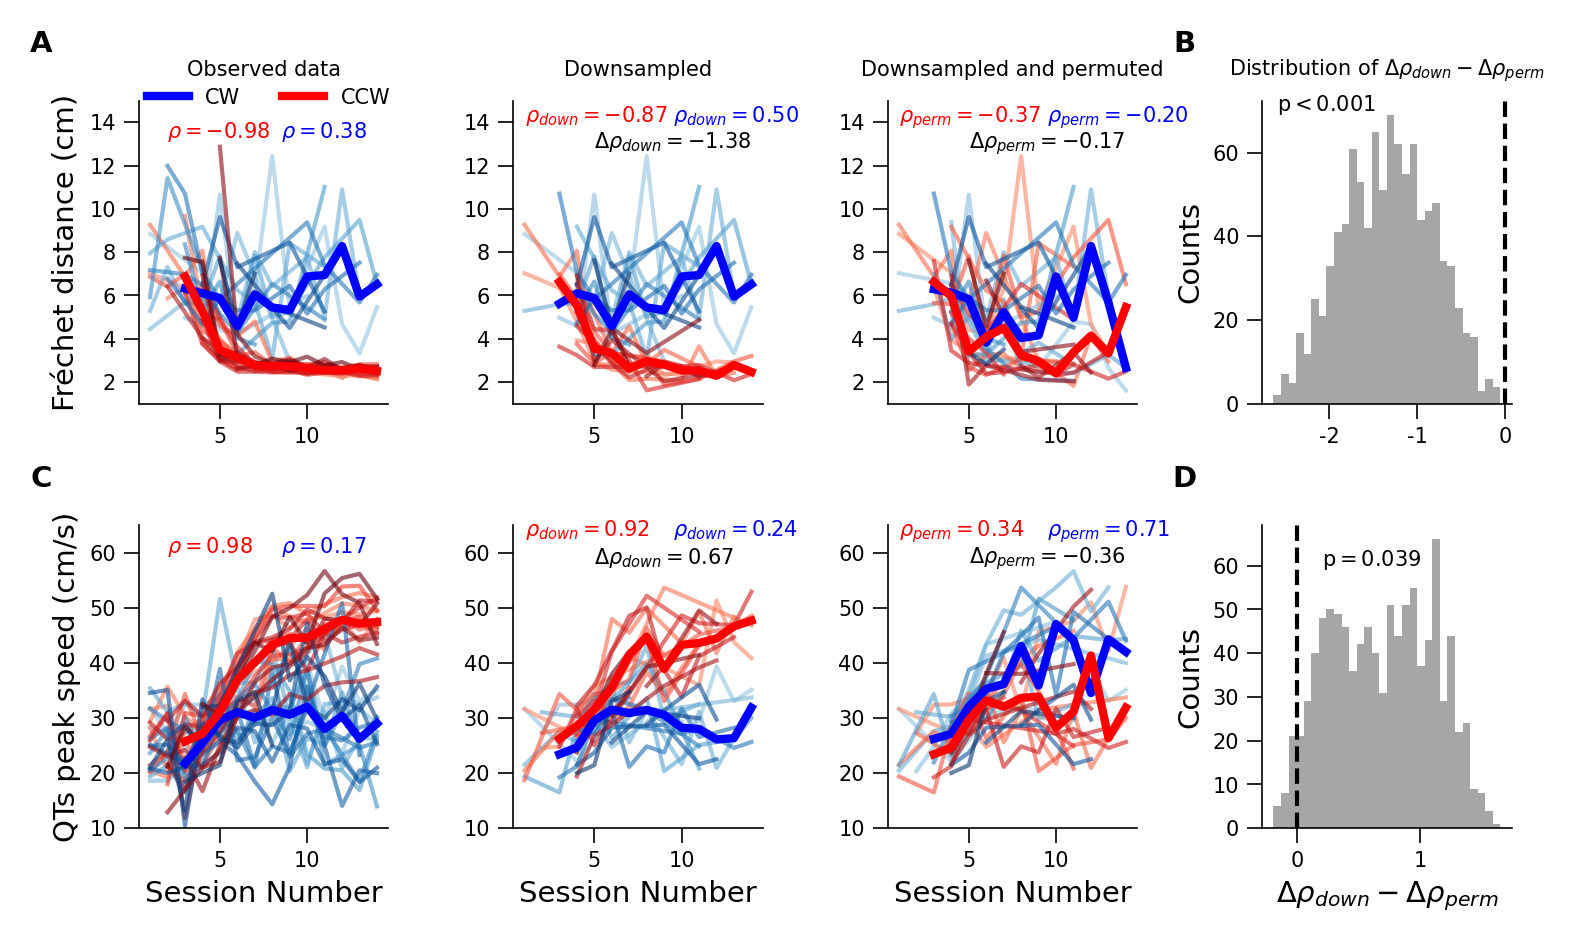

In [23]:
fig=plt.figure(figsize=(cm2inch(15), cm2inch(8)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(2, 1 , hspace=0.4, wspace=0.3)

axes_to_align = []
axes_bis_to_align = []

row1 = gs[0,0].subgridspec(1, 4, wspace=.5, hspace=.3)
ax_11 = plt.subplot(row1[0])
ax_12 = plt.subplot(row1[1])
ax_13 = plt.subplot(row1[2])
ax_14 = plt.subplot(row1[3])

### Panel A ###

plot_func_frechet_1(ax_11, median_frechet_by_mouse_session_direction, 
                    cw_text_loc=(8.5,13.3), ccw_text_loc=(2,13.3), show_xlabel=False)
axes_to_align.append(ax_11)
plot_func_frechet_2(ax_12, trajectories_per_session_realigned_rotated, 
                    swaping=False, title='Downsampled', cw_text_loc=(9.5,14), ccw_text_loc=(1,14), delta_text_loc=(5,12.8), show_xlabel=False, show_ylabel=False)
plot_func_frechet_2(ax_13, trajectories_per_session_realigned_rotated, 
                    swaping=True, title='Downsampled and permuted', cw_text_loc=(9.5,14), ccw_text_loc=(1,14), delta_text_loc=(5,12.8), show_xlabel=False, show_ylabel=False)

ax_11.set_ylim((1,15))
ax_12.set_ylim((1,15))
ax_13.set_ylim((1,15))

fig.text(0.07, 0.94, 'A', weight='bold', va='center', ha='center', fontsize=7)

### Panel B ###

with open("rho_frechet_downsampled_perm.pkl", "rb") as f:
    results = pickle.load(f)

rho_cw = results["rho_cw"]
rho_ccw = results["rho_ccw"]
rho_cw_perm = results["rho_cw_perm"]
rho_ccw_perm = results["rho_ccw_perm"]

speed_delta_down_minus_perm = (rho_ccw - rho_cw) - (rho_ccw_perm - rho_cw_perm)

# -----------------------------
# Compute fraction of iterations where delta > 0
# -----------------------------
p_value = np.mean(speed_delta_down_minus_perm >= 0)
print(f"Fraction of iterations where Δρ_down > Δρ_perm: {1 - p_value:.3f}")
print(f"p-value (Δρ_down ≤ Δρ_perm): {p_value:.4f}")

# -----------------------------
# Plot distribution
# -----------------------------

ax_14.hist(speed_delta_down_minus_perm, bins=30, color='gray', alpha=0.7)
ax_14.axvline(0, color='k', linestyle='--', label='0')
ax_14.text(-2.6, 70, rf'p$= {p_value:.3f}$' if p_value>=0.001 else 'p$<0.001$', fontsize=5)
# ax_14.set_xlabel("Δρ_down - Δρ_perm")
ax_14.set_ylabel("Counts")
ax_14.set_title(r"Distribution of $\Delta \rho_{{down}} - \Delta \rho_{{perm}}$", fontsize=5)
axes_bis_to_align.append(ax_14)

fig.text(0.715, 0.94, 'B', weight='bold', va='center', ha='center', fontsize=7)

row2 = gs[1,0].subgridspec(1, 4, wspace=.5, hspace=.3)
ax_21 = plt.subplot(row2[0])
ax_22 = plt.subplot(row2[1])
ax_23 = plt.subplot(row2[2])
ax_24 = plt.subplot(row2[3])

### Panel C ###

plot_func(ax_21, mice_all_maximum_cw_turn_speed_persession, mice_all_maximum_ccw_turn_speed_persession, 
          resampling = False, swaping = False, title = None, cw_text_loc=(8.5,60), ccw_text_loc=(2,60))
axes_to_align.append(ax_21)
plot_func(ax_22, mice_all_maximum_cw_turn_speed_persession, mice_all_maximum_ccw_turn_speed_persession, 
          resampling = True, swaping = False, title = None, cw_text_loc=(9.5,63), ccw_text_loc=(1,63), delta_text_loc=(5, 58), show_ylabel=False)
plot_func(ax_23, mice_all_maximum_cw_turn_speed_persession, mice_all_maximum_ccw_turn_speed_persession, 
          resampling = True, swaping = True, title = None, cw_text_loc=(9.5,63), ccw_text_loc=(1,63), delta_text_loc=(5, 58), show_ylabel=False)

ax_21.set_ylim((10,65))
ax_22.set_ylim((10,65))
ax_23.set_ylim((10,65))

fig.text(0.07, 0.48, 'C', weight='bold', va='center', ha='center', fontsize=7)

### Panel D ###

with open("rho_speed_downsampled_perm.pkl", "rb") as f:
    results = pickle.load(f)

rho_cw = results["rho_cw"]
rho_ccw = results["rho_ccw"]
rho_cw_perm = results["rho_cw_perm"]
rho_ccw_perm = results["rho_ccw_perm"]

speed_delta_down_minus_perm = (rho_ccw - rho_cw) - (rho_ccw_perm - rho_cw_perm)

# -----------------------------
# Compute fraction of iterations where delta > 0
# -----------------------------
p_value = np.mean(speed_delta_down_minus_perm <= 0)
print(f"Fraction of iterations where Δρ_down > Δρ_perm: {1 - p_value:.3f}")
print(f"p-value (Δρ_down ≤ Δρ_perm): {p_value:.4f}")
# -----------------------------
# Plot distribution
# -----------------------------

ax_24.hist(speed_delta_down_minus_perm, bins=30, color='gray', alpha=0.7)
ax_24.axvline(0, color='k', linestyle='--')
ax_24.text(0.2, 60, rf'p$= {p_value:.3f}$' if p_value>=0.001 else 'p$<0.001$', fontsize=5)
ax_24.set_xlabel(r"$\Delta \rho_{{down}} - \Delta \rho_{{perm}}$")
ax_24.set_ylabel("Counts")
# ax_14.set_title(r"Distribution of $\Delta \rho_{{down}} - \Delta \rho_{{perm}}$", fontsize=5)
axes_bis_to_align.append(ax_24)

fig.text(0.715, 0.48, 'D', weight='bold', va='center', ha='center', fontsize=7)

fig.align_ylabels(axes_to_align)
fig.align_ylabels(axes_bis_to_align)

# After all plotting is done, right before saving:
fig.tight_layout()
plt.savefig("FigureS01.png", facecolor='w', edgecolor='none', format="png", dpi=300)


In [24]:
# Save the figure as a PDF
fig.savefig("FigureS01.pdf", format="pdf", bbox_inches='tight', dpi=300)
